## EDA — Exploración y agregaciones

Se hace la exploración y agregaciones sobre los datos en `data/staging/`

### Imports

In [1]:
import os, socket, time
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession, functions as F

%matplotlib inline
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": .3})
pd.set_option("display.max_colwidth", 80)

### Utilidades

- Constantes

In [2]:
proyecto = Path.cwd()
while not (proyecto / "docker-compose.yml").exists() and proyecto != proyecto.parent:
    proyecto = proyecto.parent
staging_dir = proyecto / "data" / "staging"
anios = [2023, 2024, 2025]
out_dir = proyecto / "01_EDA_KDD" / "temp" / "b_exploracion"
fig_dir, tab_dir, web_dir = out_dir / "figs", out_dir / "tablas", out_dir / "web"
for d in (fig_dir, tab_dir, web_dir):
    d.mkdir(parents=True, exist_ok=True)

def mostrar_fig(nombre):
    plt.tight_layout()
    plt.savefig(fig_dir / f"{nombre}.png", dpi=150, bbox_inches="tight")
    plt.show()

def guardar_tabla(df, nombre):
    sdf = spark.createDataFrame(df) if isinstance(df, pd.DataFrame) else df
    sdf.coalesce(1).write.mode("overwrite").parquet(str(tab_dir / nombre))
    sdf.toPandas().to_json(web_dir / f"{nombre}.json", orient="records", force_ascii=False, date_format="iso", indent=1)
    return len(df) if isinstance(df, pd.DataFrame) else sdf.count()

- Spark

In [3]:
spark_master = os.environ.get("spark_master", "local[*]")

builder = (SparkSession.builder
           .appName("exploracion")
           .master(spark_master)
           .config("spark.driver.memory",   os.environ.get("SPARK_DRIVER_MEMORY", "4g"))
           .config("spark.executor.memory", os.environ.get("SPARK_EXECUTOR_MEMORY", "4g"))
           .config("spark.sql.shuffle.partitions", "24")
           .config("spark.ui.showConsoleProgress", "false")
           .config("spark.sql.session.timeZone", "America/Lima"))

if spark_master.startswith("spark://"):
    builder = (builder.config("spark.driver.host", socket.gethostname())
                      .config("spark.driver.bindAddress", "0.0.0.0"))

spark = builder.getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

### Verificación del cluster

In [4]:
sc = spark.sparkContext
estado = sc._jsc.sc().getExecutorMemoryStatus()

print(f"Master        : {sc.master}")
print(f"Executors     : {estado.size() - 1}")
print(f"Cores totales : {sc.defaultParallelism}")
print(f"Memoria driver: {sc._jvm.java.lang.Runtime.getRuntime().maxMemory() / 1024**3:.1f} GB")
print("UI del job    : http://localhost:4040")

Master        : spark://spark-master:7077
Executors     : 0
Cores totales : 2
Memoria driver: 2.0 GB
UI del job    : http://localhost:4040


### Carga del dataset

Lee los parquets de `data\staging`

In [5]:
assert staging_dir.exists(), \
    f"No se encuentra {staging_dir}; corre EDA/a_entendimiento.ipynb"

base = spark.read.parquet(str(staging_dir)).cache()
N = base.count()
base.createOrReplaceTempView("procesos")
print(f"Dataset cargado: {N:,} filas x {len(base.columns)} columnas")

Dataset cargado: 236,229 filas x 18 columnas


---
### 1. Análisis univariable

#### a. Distribución temporal

+-------------------+-------------------+
|                min|                max|
+-------------------+-------------------+
|2023-01-01 00:00:00|2026-09-13 12:05:36|
+-------------------+-------------------+



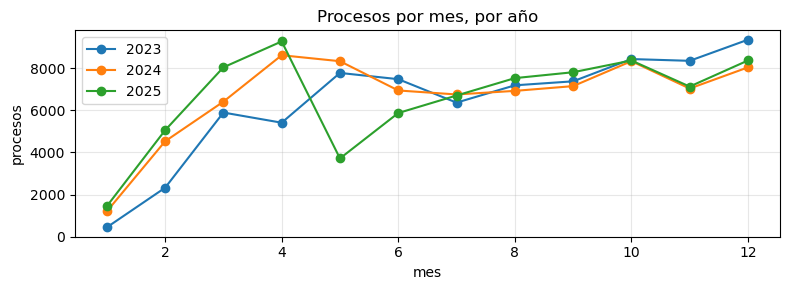

In [6]:
base.select(F.min("fecha").alias("min"), F.max("fecha").alias("max")).show()

serie = (base.where(F.col("anio").isin(anios))
         .groupBy("anio", F.month("fecha").alias("mes")).count()
         .orderBy("anio", "mes").toPandas())

plt.figure(figsize=(8, 3))
for a, g in serie.groupby("anio"):
    plt.plot(g["mes"], g["count"], marker="o", label=a)
plt.title("Procesos por mes, por año"); plt.xlabel("mes"); plt.ylabel("procesos"); plt.legend()
mostrar_fig("serie_mensual")

- Fechas de 2023-01-01 a 2026-09-13

- El grueso cae dentro de 2023-2025 como se espera; un puñado de registros cae en 2026 — fechas de adjudicación mal registradas o a futuro 

- Dentro del rango válido, el flujo es continuo mes a mes, sin huecos grandes — favorable para técnicas de minería de flujos (DGIM)

#### b. Variables categóricas

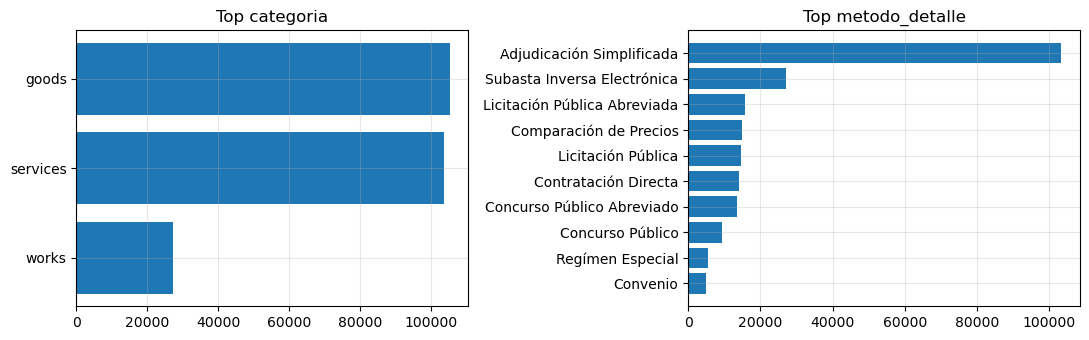

In [7]:
tops = {}
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
for i, c in enumerate(["categoria", "metodo_detalle"]):
    tops[c] = base.groupBy(c).count().orderBy(F.desc("count")).limit(10).toPandas()
    d = tops[c].iloc[::-1]
    ax[i].barh(d[c].astype(str).str[:35], d["count"]); ax[i].set_title(f"Top {c}")
mostrar_fig("categoricas")

- `categoria` solo tiene 3 valores (*services*, *goods* y *works*; bienes y servicios dominan en cantidad, obras es la minoría)

- `metodo_detalle` sí tiene cola larga: unos pocos métodos concentran la mayoría de procesos y el resto son categorías poco
usadas, consistente con lo esperado en compra pública (mayoría de procesos entra por un puñado de modalidades estándar)

#### c. Montos

Percentiles monto referencial (S/): {'p05': '47,538', 'p25': '85,983', 'p50': '186,000', 'p75': '492,887', 'p95': '4,349,816', 'p99': '1,134,909,484'}


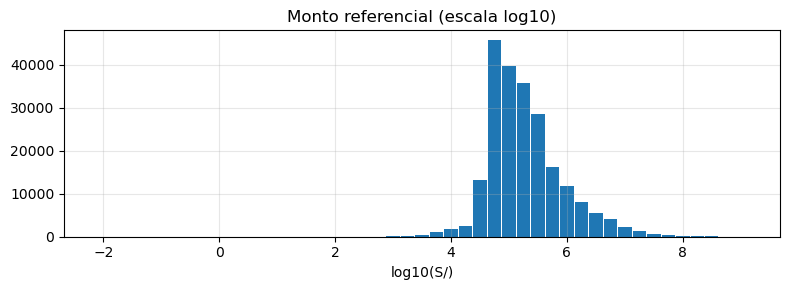

In [8]:
m = base.where(F.col("monto_referencial") > 0)
q = m.approxQuantile("monto_referencial", [.05, .25, .5, .75, .95, .99], 0.01)
print("Percentiles monto referencial (S/):", dict(zip(["p05","p25","p50","p75","p95","p99"], [f"{x:,.0f}" for x in q])))

hist = (m.groupBy((F.floor(F.log10("monto_referencial") * 4) / 4).alias("log10")).count()
        .orderBy("log10").toPandas())
plt.figure(figsize=(8, 3)); plt.bar(hist["log10"], hist["count"], width=.23)
plt.title("Monto referencial (escala log10)"); plt.xlabel("log10(S/)")
mostrar_fig("montos")

- Distribución muy sesgada a la derecha: la mediana es S/186,000 pero el p99 llega a S/1,134,909,484; unos pocos procesos extremos (probablemente obras grandes) estiran la cola

- La media no sirve como resumen; en escala log10 la distribución se ve mucho más simétrica, por eso se discretiza en en vez de usar el valor crudo

#### d. Outliers de monto

In [9]:
top_montos = (base.where("monto_referencial > 0").orderBy(F.desc("monto_referencial"))
                  .select("entidad", "categoria", "monto_referencial", "descripcion"))
top_montos.show(5, truncate=60)

+------------------------------------------------------------+---------+-----------------+------------------------------------------------------------+
|                                                     entidad|categoria|monto_referencial|                                                 descripcion|
+------------------------------------------------------------+---------+-----------------+------------------------------------------------------------+
|                       AUTORIDAD NACIONAL DE INFRAESTRUCTURA|    works|  1.13490948419E9|Diseño y Construcción del Proyecto: "Mejoramiento y ampli...|
|GOBIERNO REGIONAL DE LORETO - ORGANISMO PUBLICO INFRAESTR...|    works|  1.05766166778E9|CONTRATACIÓN DE LA EJECUCIÓN DE LA OBRA: ¿MEJORAMIENTO Y ...|
|GOBIERNO REGIONAL DE LORETO - ORGANISMO PUBLICO INFRAESTR...|    works|  1.05766166778E9|CONTRATACIÓN DE LA EJECUCIÓN DE LA OBRA: ¿MEJORAMIENTO Y ...|
|GOBIERNO REGIONAL DE LORETO - ORGANISMO PUBLICO INFRAESTR...|    works|  1.00316959571E

- Los 5 montos más altos son todos de `categoria = works`. Proyectos reales de infraestructura vial (ej. "Mejoramiento y ampliación…" de la Autoridad Nacional de Infraestructura, de S/1,000-1,135 millones)

- 2 de los 5 montos aparecen duplicados — misma entidad, **misma fecha**, mismo monto exacto y
descripción casi idéntica, pero con **`ocid` distinto**. Puede deberse a dos paquetes/lotes separados de la misma obra con descripción copiada

#### e. Frecuencia de entidades

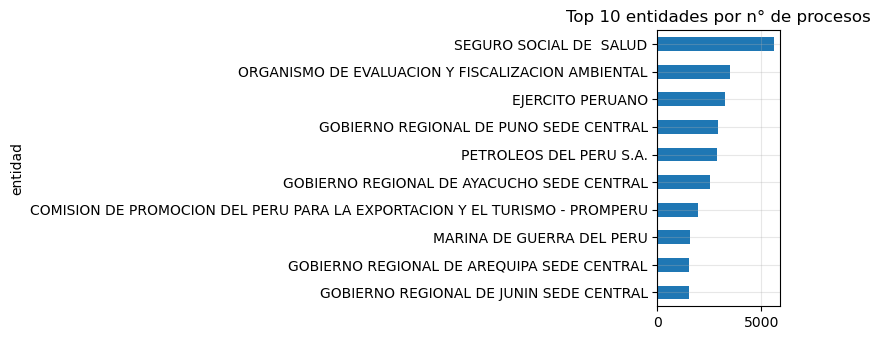

In [10]:
top_ent = spark.sql('''SELECT upper(trim(entidad)) AS entidad, COUNT(*) AS procesos
    FROM procesos GROUP BY 1 ORDER BY procesos DESC LIMIT 10''').toPandas()

top_ent.iloc[::-1].plot.barh(x="entidad", y="procesos", legend=False, figsize=(8, 3.5))
plt.title("Top 10 entidades por n° de procesos")
mostrar_fig("top_entidades")

- El top 10 lo dominan grandes organismos nacionales recurrentes: Seguro Social de Salud (5,615 procesos), Organismo de Evaluación y Fiscalización Ambiental (3,502), Ejército Peruano (3,257), seguido de gobiernos regionales (Puno, Ayacucho, Arequipa, Junín) y Petróleos del Perú. 

- Entidades con compras continuas de bajo-mediano monto (insumos, servicios recurrentes) más que proyectos únicos grandes — consistente con que sean las de más procesos, no las de mayor monto (ver §5.1/§5.2).

#### f. Frecuencia de proveedores

,n_proveedores,pct_monto_top10
0,66141,5.241068


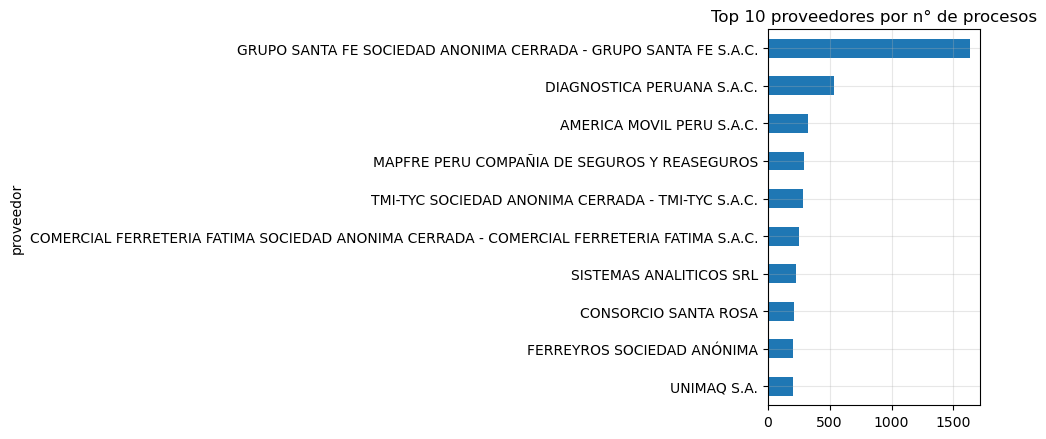

In [11]:
top_prov = spark.sql('''
    SELECT upper(trim(proveedor)) AS proveedor, COUNT(*) AS procesos
    FROM procesos WHERE proveedor IS NOT NULL GROUP BY 1 ORDER BY procesos DESC LIMIT 10''').toPandas()

conc = spark.sql('''
    WITH p AS (SELECT upper(trim(proveedor)) AS proveedor, SUM(monto_adjudicado) AS monto
               FROM procesos WHERE proveedor IS NOT NULL GROUP BY 1)
    SELECT COUNT(*) AS n_proveedores,
           SUM(CASE WHEN rk <= 10 THEN monto END) / SUM(monto) * 100 AS pct_monto_top10
    FROM (SELECT *, ROW_NUMBER() OVER (ORDER BY monto DESC) AS rk FROM p)''').toPandas()
display(conc)

top_prov.iloc[::-1].plot.barh(x="proveedor", y="procesos", legend=False, figsize=(10, 4.5))
plt.title("Top 10 proveedores por n° de procesos")
mostrar_fig("top_proveedores")

- 66,141 proveedores distintos con monto adjudicado, y el top 10 concentra solo ~5.2% del monto total adjudicado — menos concentrado de lo que se podría esperar a priori

- Por **frecuencia** sí hay proveedores que destacan. El top 10 por número de procesos no es el mismo que el top 10 por monto, lo
cual tiene sentido (muchos procesos pequeños y recurrentes vs. pocos procesos grandes)

- Bajo monto concentrado pero alta frecuencia en algunos proveedores es justo el patrón que hace candidatos razonables a mineria de flujos (heavy hitters y reincidencia) sobre `entidad`/`proveedor`

#### g. Reincidencia proveedor-entidad

In [12]:
pares = base.where("proveedor IS NOT NULL").groupBy("entidad", "proveedor").count().orderBy(F.desc("count"))
pares.show(10, truncate=40)

+----------------------------------------+----------------------------------------+-----+
|                                 entidad|                               proveedor|count|
+----------------------------------------+----------------------------------------+-----+
|COMISION DE PROMOCION DEL PERU PARA L...|          META PLATFORMS IRELAND LIMITED|  155|
|  GOBIERNO REGIONAL DE PUNO SEDE CENTRAL|GRUPO SANTA FE SOCIEDAD ANONIMA CERRA...|  153|
|COMISION DE PROMOCION DEL PERU PARA L...|                              GOOGLE LLC|  128|
|COMISION DE PROMOCION DEL PERU PARA L...|                              TIKTOK INC|  113|
|                 SEGURO SOCIAL DE  SALUD|             CARDIO PERFUSION E.I.R.LTDA|   73|
|                 SEGURO SOCIAL DE  SALUD|              DIAGNOSTICA PERUANA S.A.C.|   62|
|                 SEGURO SOCIAL DE  SALUD|                       CYMED MEDICAL SAC|   59|
|MTC-PROYECTO ESPECIAL DE INFRAESTRUCT...|             GONZALES LACA CARLOS MIGUEL|   59|
|GOBIERNO 

- Hay reincidencia real y fuerte en pares específicos: PROMPERÚ contrató 155 veces a Meta Platforms Ireland, 128 a Google LLC y 113 a TikTok Inc y así en otros casos

- A nivel de **par** entidad-proveedor, hay vínculos que se repiten cientos de veces, exactamente el patrón que mineria de flujos, "¿ya vi este par antes?" y frecuencia aproximada del par están diseñados para vigilar en streaming

#### h. Texto y códigos UNSPSC

In [13]:
txt = base.select(
    F.size(F.split(F.trim("descripcion"), r"\s+")).alias("palabras_desc"),
    F.when(F.length(F.trim("items_desc")) > 0,
           F.size(F.split(F.trim("items_desc"), r"\s+"))).alias("palabras_items"),
    F.size("unspsc").alias("n_unspsc"))

q_desc = txt.approxQuantile("palabras_desc", [.25, .5, .75, .95], .01)
n_desc_distintas = base.select("descripcion").distinct().count()
pct_items_vacio = round(100 * txt.where("palabras_items IS NULL").count() / N, 1)
q_items = txt.where("palabras_items IS NOT NULL").approxQuantile("palabras_items", [.25, .5, .75, .95], .01)
n_unspsc_distintos = base.select(F.explode("unspsc")).distinct().count()
unspsc_por_proceso = txt.groupBy("n_unspsc").count().orderBy("n_unspsc")

print("Palabras por descripción (p25, p50, p75, p95):", q_desc)
print("Descripciones distintas:", n_desc_distintas, "de", N)

print("\n% con items_desc vacío:", pct_items_vacio)
print("Palabras por items_desc, cuando existe (p25, p50, p75, p95):", q_items)

print("\nCódigos UNSPSC distintos:", n_unspsc_distintos)
unspsc_por_proceso.show(5)

Palabras por descripción (p25, p50, p75, p95): [18.0, 29.0, 40.0, 50.0]
Descripciones distintas: 190740 de 236229

% con items_desc vacío: 0.0
Palabras por items_desc, cuando existe (p25, p50, p75, p95): [12.0, 24.0, 36.0, 52.0]

Códigos UNSPSC distintos: 5175
+--------+------+
|n_unspsc| count|
+--------+------+
|       0| 36467|
|       1|193160|
|       2|  4666|
|       3|   808|
|       4|   312|
+--------+------+
only showing top 5 rows



- `descripcion` siempre existe y tiene una mediana de 29 palabras; 190,740 descripciones distintas de 236,229 (~81% son únicas)

- `items_desc` también está 100% poblado (0% vacío) con una mediana de 24 palabras; comparable en volumen a `descripcion`

- `unspsc` es pobre como conjunto: 193,160 procesos (82%) tienen exactamente 1 código y 36,467 (15%) no tienen ninguno; muy pocos tienen 2 o más

### 2. Análisis multivariable

#### a. Comparación entre años

In [14]:
por_anio = (base.where(F.col("anio").isin(anios)).groupBy("anio").agg(
        F.count("*").alias("procesos"),
        F.countDistinct("entidad").alias("entidades"),
        F.countDistinct("proveedor").alias("proveedores"),
        F.round(F.expr("percentile_approx(monto_referencial, 0.5)"), 0).alias("monto_mediano"),
        F.round(100 * F.avg(F.when(F.col("n_postores") == 1, 1).otherwise(0)), 1).alias("%_postor_unico"))
      .orderBy("anio").toPandas())
por_anio

,anio,procesos,entidades,proveedores,monto_mediano,%_postor_unico
0,2023,76390,2633,28804,159656.0,12.3
1,2024,80263,2749,31293,166058.0,10.3
2,2025,79301,2822,31187,185624.0,10.9


- Los tres años tienen volumen similar (76-80 mil procesos)

- El `%_postor_unico` baja de 12.3% (2023) a 10.9% (2025) — leve mejora en competencia, pero el patrón de baja competencia es
estructural. 

- El monto mediano sube cada año (159,656 → 185,624), más rápido que la cantidad de entidades/proveedores (que crece poco)

- Indicio de que el alza no es solo por más procesos, sino por montos más altos en los mismos actores

#### b. Monto por categoría

In [15]:
monto_categoria = (base.where("monto_referencial > 0").groupBy("categoria").agg(F.count("*").alias("procesos"),
                   F.round(F.expr("percentile_approx(monto_referencial, 0.5)"), 0).alias("monto_mediano"))
                   .orderBy(F.desc("procesos")))
monto_categoria.show()

+---------+--------+-------------+
|categoria|procesos|monto_mediano|
+---------+--------+-------------+
| services|   98222|     168000.0|
|    goods|   95118|     150920.0|
|    works|   26686|    1417087.0|
+---------+--------+-------------+



- *Works* tiene casi 4x el monto mediano de *goods*/*services* (S/1,417,087 vs ~S/150-168k) con muchos menos procesos (26,686 vs ~95-98k cada una)
 
- Vecinos aproximados (ANN) deberían compararse dentro de la misma categoría, porque la escala de montos es muy distinta

#### c. Competencia vs. tramo de monto

In [16]:
tramos = (base
    .withColumn("tramo", F.when(F.col("monto_referencial").isNull() | (F.col("monto_referencial") <= 0), "0_sin_monto")
                         .when(F.col("monto_referencial") <    50_000, "1_<50k")
                         .when(F.col("monto_referencial") <   200_000, "2_50k-200k")
                         .when(F.col("monto_referencial") < 1_000_000, "3_200k-1M")
                         .when(F.col("monto_referencial") < 5_000_000, "4_1M-5M")
                         .otherwise("5_>5M"))
    .groupBy("tramo")
    .agg(F.count("*").alias("procesos"),
         F.round(100 * F.avg(F.when(F.col("n_postores") == 1, 1).otherwise(0)), 1).alias("%_postor_unico"))
    .orderBy("tramo"))
tramos.show()

+-----------+--------+--------------+
|      tramo|procesos|%_postor_unico|
+-----------+--------+--------------+
|0_sin_monto|   16203|           6.9|
|     1_<50k|   12916|          57.3|
| 2_50k-200k|   99974|           9.8|
|  3_200k-1M|   72260|           7.7|
|    4_1M-5M|   24619|           8.0|
|      5_>5M|   10257|           6.8|
+-----------+--------+--------------+



- Relación clara y no lineal: el tramo `1_<50k` tiene 57.3% de postor único — casi el quíntuple que el resto

- Los procesos sin monto (`0_sin_monto`) tienen 6.9% — el tramo *más bajo* de todos

- los procesos pequeños concentran la baja competencia, justo el patrón que apoya las reglas de asociación capturando reglas como `{tramo=1_<50k} → {postor único}`.

#### Método vs. competencia

In [17]:
competencia_metodo = (base.groupBy("metodo_detalle").agg(F.count("*").alias("procesos"),
                      F.round(100 * F.avg(F.when(F.col("n_postores") == 1, 1).otherwise(0)), 1).alias("%_postor_unico"))
                      .where("procesos >= 100").orderBy(F.desc("procesos")))
competencia_metodo.show(10, truncate=40)

+----------------------------+--------+--------------+
|              metodo_detalle|procesos|%_postor_unico|
+----------------------------+--------+--------------+
|   Adjudicación Simplificada|  103367|           1.5|
| Subasta Inversa Electrónica|   27042|           2.1|
|Licitación Pública Abreviada|   15719|           1.5|
|      Comparación de Precios|   14778|           1.0|
|          Licitación Pública|   14671|           0.4|
|        Contratación Directa|   14005|          86.5|
|  Concurso Público Abreviado|   13648|           1.5|
|            Concurso Público|    9478|           0.5|
|            Regímen Especial|    5562|          80.0|
|                    Convenio|    4956|          54.6|
+----------------------------+--------+--------------+
only showing top 10 rows



- Los métodos **competitivos** (Adjudicación Simplificada, Subasta Inversa, Licitación Pública, Concurso Público) tienen entre 0.4% y 2.1% de postor único — casi siempre hay varios postores, como exige su diseño

- **Contratación Directa** (86.5%), **Régimen Especial** (80.0%) y **Convenio** (54.6%) tienen porcentajes altísimos, porque esas modalidades están pensadas para adjudicar sin competir

- `metodo_detalle` solo, sin cruzarlo con monto ni región, ya separa casi perfectamente los procesos de baja competencia

### 3. Agregaciones: RDD/DataFrame/SQL

#### a. Frecuencia de procesos por entidad

In [18]:
t0 = time.time()
rdd_a = (base.rdd.map(lambda r: (r.entidad, 1))
             .reduceByKey(lambda a, b: a + b)
             .takeOrdered(10, key=lambda kv: -kv[1]))
t_rdd_a = time.time() - t0

t0 = time.time()
df_a = base.groupBy("entidad").count().orderBy(F.desc("count")).limit(10).collect()
t_df_a = time.time() - t0

t0 = time.time()
sql_a = spark.sql("SELECT entidad, COUNT(*) AS n FROM procesos GROUP BY entidad ORDER BY n DESC LIMIT 10").collect()
t_sql_a = time.time() - t0

print(f"RDD       : {t_rdd_a:.2f}s | top1 = {rdd_a[0]}")
print(f"DataFrame : {t_df_a:.2f}s | top1 = {(df_a[0]['entidad'], df_a[0]['count'])}")
print(f"SQL       : {t_sql_a:.2f}s | top1 = {(sql_a[0]['entidad'], sql_a[0]['n'])}")

assert rdd_a[0][1] == df_a[0]["count"] == sql_a[0]["n"], "los 3 enfoques deben coincidir"
print("Los 3 enfoques coinciden ✓")

RDD       : 2.39s | top1 = ('SEGURO SOCIAL DE  SALUD', 5615)
DataFrame : 0.23s | top1 = ('SEGURO SOCIAL DE  SALUD', 5615)
SQL       : 0.19s | top1 = ('SEGURO SOCIAL DE  SALUD', 5615)
Los 3 enfoques coinciden ✓


- Se identifica las entidades que concentran más volumen de procesos, las prioritarias a revisar

- Pretende revisar si en estas entidades se concenta la baja competencia y ver si existen estos procesos duplicados

- El top 1 es Seguro Social de Salud con 5,615 procesos

#### b. Monto total adjudicado por año

In [19]:
t0 = time.time()
rdd_b = dict(base.rdd.map(lambda r: (r.anio, r.monto_adjudicado or 0.0))
                 .reduceByKey(lambda a, b: a + b)
                 .collect())
t_rdd_b = time.time() - t0

t0 = time.time()
df_b = {r["anio"]: r["total"] for r in
        base.groupBy("anio").agg(F.sum("monto_adjudicado").alias("total")).collect()}
t_df_b = time.time() - t0

t0 = time.time()
sql_b = {r["anio"]: r["total"] for r in
         spark.sql("SELECT anio, SUM(monto_adjudicado) AS total FROM procesos GROUP BY anio").collect()}
t_sql_b = time.time() - t0

print("RDD       :", {k: round(v) for k, v in sorted(rdd_b.items())}, f"({t_rdd_b:.2f}s)")
print("DataFrame :", {k: round(v) for k, v in sorted(df_b.items())}, f"({t_df_b:.2f}s)")
print("SQL       :", {k: round(v) for k, v in sorted(sql_b.items())}, f"({t_sql_b:.2f}s)")

for a in anios:
    assert abs(rdd_b.get(a, 0) - df_b.get(a, 0)) < 1, f"RDD y DataFrame difieren en {a}"
    assert abs(df_b.get(a, 0) - sql_b.get(a, 0)) < 1, f"DataFrame y SQL difieren en {a}"
print("Los 3 enfoques coinciden ✓")

RDD       : {2023: 71080969917, 2024: 87308562790, 2025: 81800102752, 2026: 438004475} (1.31s)
DataFrame : {2023: 71080969917, 2024: 87308562790, 2025: 81800102752, 2026: 438004475} (0.13s)
SQL       : {2023: 71080969917, 2024: 87308562790, 2025: 81800102752, 2026: 438004475} (0.10s)
Los 3 enfoques coinciden ✓


- Se cuantifica cuánto dinero público está realmente en juego cada año (S/71-87 mil millones)

- Enfoque en revisar qué parte de ese monto total, corresponde a procesos con un solo postor

- Revisar si las diferencias de precio entre compras parecidas son relevantes en soles

#### c. Competencia (% postor único) por región

In [20]:
t0 = time.time()
rdd_c = dict(base.rdd
             .filter(lambda r: r.region is not None)
             .map(lambda r: (r.region, (1 if r.n_postores == 1 else 0, 1)))
             .reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1]))
             .filter(lambda kv: kv[1][1] >= 100)
             .mapValues(lambda v: round(100 * v[0] / v[1], 1))
             .collect())
t_rdd_c = time.time() - t0

t0 = time.time()
df_c = (base.where("region IS NOT NULL").groupBy("region")
        .agg(F.round(100 * F.avg(F.when(F.col("n_postores") == 1, 1).otherwise(0)), 1).alias("pct_postor_unico"),
             F.count("*").alias("procesos"))
        .where("procesos >= 100")
        .orderBy(F.desc("pct_postor_unico")))
t_df_c = time.time() - t0
df_c_pd = df_c.toPandas()

t0 = time.time()
sql_c_pd = spark.sql('''
    SELECT region, ROUND(100*AVG(CASE WHEN n_postores=1 THEN 1 ELSE 0 END),1) AS pct_postor_unico,
           COUNT(*) AS procesos
    FROM procesos WHERE region IS NOT NULL GROUP BY region HAVING procesos >= 100
    ORDER BY pct_postor_unico DESC''').toPandas()
t_sql_c = time.time() - t0

sql_dict = dict(zip(sql_c_pd["region"], sql_c_pd["pct_postor_unico"]))
for region, pct in zip(df_c_pd["region"], df_c_pd["pct_postor_unico"]):
    assert abs(rdd_c[region] - pct) < 0.15, f"RDD y DataFrame difieren en {region}"
    assert abs(sql_dict[region] - pct) < 0.15, f"DataFrame y SQL difieren en {region}"
print("Los 3 enfoques coinciden ✓")
print(f"RDD       : {t_rdd_c:.2f}s")
print(f"DataFrame : {t_df_c:.2f}s")
print(f"SQL       : {t_sql_c:.2f}s\n")
df_c_pd.head(10)

Los 3 enfoques coinciden ✓
RDD       : 1.26s
DataFrame : 0.02s
SQL       : 0.24s



,region,pct_postor_unico,procesos
0,TUMBES,30.7,997
1,LIMA,26.3,68658
2,CONTRALMIRANTE VILLAR,25.7,140
3,ZARUMILLA,22.9,179
4,PACASMAYO,17.0,206
5,TRUJILLO,14.2,4933
6,CONTUMAZA,13.9,237
7,HUAROCHIRI,12.4,372
8,CHACHAPOYAS,12.3,1460
9,MORROPON,12.0,857


- Tumbes encabeza con 30.7% de postor único, seguido de Lima (26.3%)

- Se identifica Lima como la región con más volumen y, en teoría, más proveedores disponibles para competir, que
tiene una de las tasas de baja competencia más altas del país — más del doble del promedio general (~11%)

- Contralmirante Villar (25.7%) y Zarumilla (22.9%), ambas fronterizas con Tumbes, completan el top. `region` es un buen candidato más para reglas de asociación junto a `metodo_detalle` y tramo de monto

#### d. Análisis

- Los 3 enfoques coinciden exactamente en los resultados

- RDD es siempre el más lento. En la ultima agregacion la brecha es mayor porque DataFrame reutiliza `base` ya cacheado en          columnar, mientras RDD serializa cada fila a un objeto Python

- DataFrame y SQL rinden parecido entre sí; RDD no pasa por ningún plan optimizado

- RDD exige escribir manualmente el map/reduce; DataFrame/SQL son declarativos. La brecha de expresividad crece con la complejidad.La ultima agregacion necesita 4 pasos encadenados en RDD contra una sola cadena `groupBy().agg().where()` en DataFrame

### 4. Escritura de resultados

Se guardan las tablas en `01_EDA_KDD/temp/b_exploracion/tablas/` (parquet) y `01_EDA_KDD/temp/b_exploracion/web/` (json, para la página web) — las figuras ya se guardaron en `figs/` al mostrarse

In [21]:
tablas = {
    "serie_mensual": serie,
    "top_categoria": tops["categoria"],
    "top_metodo_detalle": tops["metodo_detalle"],
    "montos_percentiles": pd.DataFrame([dict(zip(["p05", "p25", "p50", "p75", "p95", "p99"], q))]),
    "montos_hist_log10": hist,
    "top_montos": top_montos.limit(20),
    "top_entidades": top_ent,
    "top_proveedores": top_prov,
    "concentracion_proveedores": conc,
    "pares_entidad_proveedor": pares.limit(50),
    "texto_stats": pd.DataFrame([{
        "desc_p25": q_desc[0], "desc_p50": q_desc[1], "desc_p75": q_desc[2], "desc_p95": q_desc[3],
        "desc_distintas": n_desc_distintas, "pct_items_vacio": pct_items_vacio,
        "items_p25": q_items[0], "items_p50": q_items[1], "items_p75": q_items[2], "items_p95": q_items[3],
        "unspsc_distintos": n_unspsc_distintos}]),
    "unspsc_por_proceso": unspsc_por_proceso,
    "por_anio": por_anio,
    "monto_categoria": monto_categoria,
    "competencia_tramo": tramos,
    "competencia_metodo": competencia_metodo,
    "competencia_region": df_c_pd,
    "monto_adjudicado_anio": pd.DataFrame(sorted(df_b.items()), columns=["anio", "monto_adjudicado"]),
    "tiempos_rdd_df_sql": pd.DataFrame([
        ("procesos_por_entidad", t_rdd_a, t_df_a, t_sql_a),
        ("monto_por_anio", t_rdd_b, t_df_b, t_sql_b),
        ("postor_unico_por_region", t_rdd_c, t_df_c, t_sql_c)],
        columns=["agregacion", "rdd_s", "dataframe_s", "sql_s"]),
}

escritos = {nombre: guardar_tabla(df, nombre) for nombre, df in tablas.items()}
print(f"Escrito en 01_EDA_KDD/temp/b_exploracion/: {', '.join(escritos)}")

Escrito en 01_EDA_KDD/temp/b_exploracion/: serie_mensual, top_categoria, top_metodo_detalle, montos_percentiles, montos_hist_log10, top_montos, top_entidades, top_proveedores, concentracion_proveedores, pares_entidad_proveedor, texto_stats, unspsc_por_proceso, por_anio, monto_categoria, competencia_tramo, competencia_metodo, competencia_region, monto_adjudicado_anio, tiempos_rdd_df_sql


#### a. Verificación

In [22]:
for nombre, n in escritos.items():
    leido = spark.read.parquet(str(tab_dir / nombre)).count()
    assert leido == n, f"{nombre}: esperaba {n}, leí {leido}"
    assert (web_dir / f"{nombre}.json").exists(), f"falta web/{nombre}.json"

figs = sorted(p.stem for p in fig_dir.glob("*.png"))
print(f"OK: {len(escritos)} tablas (parquet + json)" + (f" | {len(figs)} figuras: {', '.join(figs)}" if figs else ""))

OK: 19 tablas (parquet + json) | 5 figuras: categoricas, montos, serie_mensual, top_entidades, top_proveedores


---
### 5. Cerrar sesión

In [23]:
spark.stop()